---
numbering: false
---

# 4.3. Vector Spaces, Basis, and Dimension

In [Chapter 4.1](./01-span.ipynb) and [Chapter 4.2](./02-linear-independence.ipynb), I introduced the key ideas of span and linear independence. In this section, we'll revisit these ideas from a more abstract and rigorous perspective.

## Context

You might be wondering what the point of all of this is – spans, linear independence, vector spaces, etc. What does any of this have to do with machine learning, or more specifically, that problem of predicting commute times given departure times from [Chapter 1.2](../01_introduction_to_supervised_learning/02-squared-loss-constant-model.ipynb)?

Remember, what we're working towards is being able to build hypothesis functions that use multiple features to make predictions.

$$\text{predicted commute time}_i \\ = h(\text{departure hour}_i, \text{day of month}_i, \text{day of week}_i, \text{gas left in tank}_i, ...)$$

As we'll see in Chapter 7, such a hypothesis function involves computing a **linear combination** of the features. To find the best possible model, we'll need to find the best possible linear combination of the features, and to do so, we'll need to think about the space of all possible linear combinations of the features – or the **span** of those features.

At times, what I'm discussing will sound abstract, pedantic, and disconnected from our overarching focus on machine learning. But bear with me – I promise it'll all come together soon.

---

## Vector Spaces

When we first introduced vectors back in [Chapter 3.1](../03_vectors/01-vectors-and-linear-combinations.ipynb), I mentioned that they support two key operations: addition and scalar multiplication. These two operations combine through **linear combinations**, as we've seen repeatedly throughout Chapter 3 so far. 

So far, we've mostly dealt with **Euclidean vectors**, which are the vectors that we've treated as ordered lists of numbers in $\mathbb{R}^n$.  (The term "Euclidean" refers to the fact that the vectors have some geometric meaning; we have thought of a vector as an arrow from the origin to a point in space. The term Euclidean is named after the Greek mathematician Euclid, who was one of the pioneers of the study of geometry.)

$$\underbrace{\vec v = \begin{bmatrix} 3 \\ -2 \\ 8 \\ 5 \\ 3 \end{bmatrix}, \quad \vec x = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}}_\text{Euclidean vectors}$$

However, it's sometimes useful to consider vectors in a more abstract setting. Euclidean vectors are not the only mathematica objects that support addition and scalar multiplication!

:::{note} Definition: Vector Space

A **vector space** is a set of objects $V$ where:
1. We can add any two elements of $V$ and the result is also an element of $V$.

$${\color{orange} \vec u}, {\color{#3d81f6} \vec v} \in V \implies {\color{orange} \vec u} + {\color{#3d81f6} \vec v} \in V$$
2. We can multiply any element of $V$ by a scalar $c$ and the result is also an element of $V$.

$${\color{#3d81f6} \vec v} \in V, \quad c \in \mathbb{R} \implies c {\color{#3d81f6} \vec v} \in V$$
:::

Together, the two properties above tell us that **any linear combination of vectors in $V$ is also a vector in $V$**.

$${\color{orange} \vec u}, {\color{#3d81f6} \vec v} \in V, \quad c, d \in \mathbb{R} \implies c {\color{orange} \vec u} + d {\color{#3d81f6} \vec v} \in V$$

$\mathbb{R}^2$ is a vector space: if you take any two vectors in $\mathbb{R}^2$ and add them together, you will still have a vector in $\mathbb{R}^2$. Multiply a vector in $\mathbb{R}^2$ by a scalar, and you'll still have a vector in $\mathbb{R}^2$.


$$\underbrace{{\color{orange}\vec u = \begin{bmatrix} 3 \\ 4 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v = \begin{bmatrix} -1 \\ 2 \end{bmatrix}}}_\text{two vectors in $\mathbb{R}^2$}$$

$$\underbrace{2 {\color{orange}\vec u} - 3 {\color{#3d81f6}\vec v} = \begin{bmatrix} 9 \\ 2 \end{bmatrix}}_\text{also a vector in $\mathbb{R}^2$!}$$

The same holds for $\mathbb{R}^3$, $\mathbb{R}^4$, and more generally, $\mathbb{R}^n$. These are all examples of vector spaces.

What might be a vector space that isn't made up of our regular Euclidean vectors? One possible vector space is the set of all polynomials with a **degree less than or equal to 3** (i.e. degree "at most 3"). This vector space, denoted by $\mathcal{P}_3$, is the set of all polynomials of the form $$p(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3$$ where $a_3, a_2, a_1, a_0$ are real numbers (potentially equal to 0).

$$u(x) = 2x^3 - 16x^2 + 7x - 1$$

$$v(x) = 3x^3 - 4x^2 + 2x + 5$$

$$w(x) = x + 4$$

$u(x)$, $v(x)$, and $w(x)$ are all elements of $\mathcal{P}_3$; think of each of these polynomials as a vector in $\mathcal{P}_3$.

Why is $\mathcal{P}_3$ a vector space? If you add any two polynomials with a degree of at most 3 together, you will still have a polynomial with degree at most 3. Likewise, if you multiply a polynomial with degree at most 3 by a scalar, you will still have a polynomial with degree at most 3.

:::{tip} Activity 1
:class: dropdown
Why are the set of polynomials of degree **exactly** 3 **not** a vector space?

:::{seealso} Solution
:class: dropdown

It's possible to add two polynomials with degree exactly 3 together, and get a polynomial with degree 2, which would mean that the result is not in the set of polynomials with degree exactly 3.

$$u(x) = x^3 + x^2 - 15$$

$$v(x) = -x^3 + 4$$

Here, $u(x) + v(x) = x^2 + 11$, which is not a polynomial with degree exactly 3.
:::

There are other examples of abstract vector spaces, too, like the set of all matrices with real entries, or the set of all continuous functions from $\mathbb{R}$ to $\mathbb{R}$. In the definition of a vector space, I mentioned that the objects in the space should support addition and scalar multiplication. We know how these operations work for our traditional definition of vectors, but what do these operations look like for generic mathematical objects?

:::{note} Vector Space Properties
In order for a set of objects $V$ to be a vector space, their definitions of addition and scalar multiplication must satisfy the following 8 properties, for elements ${\color{orange} \vec u}, {\color{#3d81f6} \vec v}, {\color{#d81b60} \vec w} \in V$ and scalars $c, d \in \mathbb{R}$.


| | Property | Description |
| --- | ---|---|
| 1 | ${\color{orange} \vec u} + {\color{#3d81f6} \vec v} = {\color{#3d81f6} \vec v} + {\color{orange} \vec u}$ | **Addition is commutative**, i.e. you can swap the order of addition |
| 2 | $({\color{orange} \vec u} + {\color{#3d81f6} \vec v}) + {\color{#d81b60} \vec w} = {\color{orange} \vec u} + ({\color{#3d81f6} \vec v} + {\color{#d81b60} \vec w})$ | **Addition is associative**, i.e. it doesn't matter how you group the vectors you're adding |
| 3 | There exists an element $\vec 0 \in V$ such that ${\color{#3d81f6} \vec v} + \vec 0 = {\color{#3d81f6} \vec v}$ for all ${\color{#3d81f6} \vec v} \in V$ | There exists an **additive identity**, i.e. a zero vector |
| 4 | For every ${\color{#3d81f6} \vec v} \in V$, there exists an element $-{\color{#3d81f6} \vec v} \in V$ such that ${\color{#3d81f6} \vec v} + (-{\color{#3d81f6} \vec v}) = \vec 0$ | There exist **additive inverses**, i.e. subtracting a vector is the same as adding its negative |
| 5 | $1 {\color{orange} \vec u} = {\color{orange} \vec u}$ | Existence of a **multiplicative identity**, i.e. multiplying a vector by the scalar 1 doesn't change the vector |
| 6 | $(cd){\color{#3d81f6} \vec v} = c(d {\color{#3d81f6} \vec v})$ | **Scalar multiplication is associative**, i.e. it doesn't matter how you group the scalars you're multiplying by |
| 7 | $c({\color{orange} \vec u} + {\color{#3d81f6} \vec v}) = c{\color{orange} \vec u} + c{\color{#3d81f6} \vec v}$ | **Scalar multiplication distributes over vector addition**, i.e. you can distribute a scalar over a sum of vectors |
| 8 | $(c + d){\color{#3d81f6} \vec v} = c{\color{#3d81f6} \vec v} + d{\color{#3d81f6} \vec v}$ | **Scalar addition distributes over scalar multiplication**, i.e. you can distribute a sum of scalars over a vector |
:::

Technically, we could be even more abstract and not restrict the scalars to be real numbers, and instead allow them to be complex numbers. Such a vector space is called a **complex vector space**. But, we'll stick with **real vector spaces** in this class, where the scalars involved in scalar multiplication are real numbers.

And even more practically, we'll stick to focusing on the vector space $\mathbb{R}^n$. Still, I wanted to provide you with some context for how to generalize these ideas.

:::{tip} Activity 2
:class: dropdown
1. Suppose we _try_ to create a new vector space in which vector addition is defined in the following way:

    $${\color{orange}\begin{bmatrix} u_1 \\ u_2 \end{bmatrix}} + {\color{#3d81f6} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix}} = \begin{bmatrix} {\color{orange}u_1} + {\color{#3d81f6}v_2} \\ {\color{orange}u_2} + {\color{#3d81f6}v_1} \end{bmatrix}$$

    So for example $\begin{bmatrix} 1 \\ 2 \end{bmatrix} + \begin{bmatrix} 3 \\ 4 \end{bmatrix} = \begin{bmatrix} 1 + 4 \\ 2 + 3 \end{bmatrix} = \begin{bmatrix} 5 \\ 5 \end{bmatrix}$.

    Suppose we stick with the usual definition of scalar multiplication. Which of the 8 conditions above are not satisfied?

2. Suppose we consider the set of vectors with two components, where scalar multiplication is defined as

    $$k {\color{#3d81f6}\begin{bmatrix} v_1 \\ v_2 \end{bmatrix}} = \begin{bmatrix} k {\color{#3d81f6}v_1} \\ {\color{#3d81f6}v_2} \end{bmatrix}$$

    Suppose we stick with the usual definition of vector addition. Which of the 8 conditions above are not satisfied?
:::

---

## Subspaces

As I emphasized above, we'll stick to working with vector spaces of the form $\mathbb{R}^n$, made up of Euclidean vectors.

A theme that we've studied over the past few sections is that of a subspace: a subset of a vector space. 

- The span of one vector in $\mathbb{R}^2$ is a line through the origin, which is a 1-dimensional subspace of $\mathbb{R}^2$.
- The span of two non-collinear vectors in $\mathbb{R}^3$ is a plane through the origin, which is a 2-dimensional subspace of $\mathbb{R}^3$.

Let me be a bit more precise with what a subspace is, given our new framing of vector spaces.

:::{note} Definition: Subspace

A subspace $S$ of a vector space $V$ is a set of vectors in $V$ where:

1. The zero vector is in $S$.

$$\vec 0 \in S$$

1. We can add any two elements of $S$ and the result is also an element of $S$.

$$\vec u, \vec v \in S \implies \vec u + \vec v \in S$$
2. We can multiply any element of $S$ by a scalar $c$ and the result is also an element of $S$.

$$\vec u \in S, c \in \mathbb{R} \implies c \vec u \in S$$

The last two properties together tell us that **$S$ must be "closed" under addition and scalar multiplication**, i.e. the must satisfy the "closure" property.
:::

**The simpler way of thinking of Properties 2 and 3 above is that if you take any two vectors $\vec u, \vec v \in S$, then any linear combination $c\vec u + d\vec v$ must also be in $S$.** If you combine elements in a subspace, they can't "escape" the subspace.

<img src="imgs/subspaces.svg" alt="Subspace" width="300" height="200">

Properties 2 and 3 above sound familiar, since they were the defining properties of a vector space. **Indeed, a subspace is a vector space on its own, it's just that it's also a subset of a larger vector space**, meaning all of its elements are also in $V$. The "sub" in "subspace" means "under" or "within". A subspace can also just be the entire vector space itself – $\mathbb{R}^2$ is a subspace of $\mathbb{R}^2$, for example – which is why I'll usually phrase definitions and theorems in terms of subspaces, rather than vector spaces.

Sometimes, other math texts will use set notation to denote subspaces, like $S \subseteq V$, but I'll try and avoid unnecessary notation like that here.

Many years ago, one of the great math teachers I had used the following example to explain what the term **closure** meant:

> If you put two elephants in a cage, and one day a third animal comes out, that third animal must still be an elephant. - [J. Bruce White](https://www.familiesfirst.ca/memorials/j-bruce-white/5608620/), 1938-2025

The point is not just that elephants are animals, but that if you take any two elephants and add them together, you'll still have an elephant.

Let's look at several _possible_ subspaces of larger vector spaces, and see if they are subspaces (and if not, why not).

:::{attention} Try these examples yourself before looking at the solutions!
While these examples aren't framed as activities, if you're reviewing after lecture or lab, try and determine whether each of these sets are subspaces _without_ reading my answer.
:::

### Example: First Component is 1 ❌

Is the set of all vectors in $\mathbb{R}^2$ whose first component is 1 a subspace of $\mathbb{R}^2$? (Notice that when I ask whether a set is a subspace, I have to specify the vector space it's possibly a subspace **of**.)

In set notation, I could write this set as

$$\{ \begin{bmatrix} 1 \\ y \end{bmatrix} \mid y \in \mathbb{R} \}$$

When I'm presented with a set like this, I like to think of some example vectors in the set, and see if those examples satisfy the properties of a subspace. **If** those examples satisfy the properties, then I'll try and prove that the properties hold for any two vectors in the set.

This set contains vectors like $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ -5 \end{bmatrix}$. Remember, for this set to be a subspace, it must be closed under addition and scalar multiplication. But, if I add these two example vectors together, I get

$$\begin{bmatrix} 1 \\ 2 \end{bmatrix} + \begin{bmatrix} 1 \\ -5 \end{bmatrix} = \begin{bmatrix} 2 \\ -3 \end{bmatrix}$$

which is not a vector in the set, since its first component is not 1. So, this set is not closed under addition, and so it is <span style="color:orange; font-weight:bold">not a subspace</span> of $\mathbb{R}^2$. I don't need to prove anything in a more general form here, since I've found a counterexample.

Also, this set doesn't contain the zero vector $\begin{bmatrix} 0 \\ 0 \end{bmatrix}$, which it needs to in order to be a subspace.

### Example: First Component is 0 ✅

Is the set of all vectors in $\mathbb{R}^2$ whose first component is 0 a subspace of $\mathbb{R}^2$? This is the set

$$\{ \begin{bmatrix} 0 \\ y \end{bmatrix} \mid y \in \mathbb{R} \}$$

This set _does_ contain the zero vector $\begin{bmatrix} 0 \\ 0 \end{bmatrix}$, which is a good start.

Some example vectors in this set are $\begin{bmatrix} 0 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 0 \\ -5 \end{bmatrix}$. Adding these vectors together gives $\begin{bmatrix} 0 \\ -3 \end{bmatrix}$, which is also in the set. 

That's a good start – but can we verify that **any linear combination** of vectors in the set is another vector in the set?

To do so, let's pick two arbitrary vectors in the set, $\vec u = \begin{bmatrix} 0 \\ x \end{bmatrix}$ and $\vec v = \begin{bmatrix} 0 \\ y \end{bmatrix}$. A linear combination of these two vectors is $c \vec u + d \vec v$, or

$$c\begin{bmatrix} 0 \\ x \end{bmatrix} + d\begin{bmatrix} 0 \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ cx + dy \end{bmatrix}$$

No matter what scalars $c$ and $d$ we pick, and no matter what the values of scalars $x$ and $y$ are, the sum $c \vec u + d \vec v$ is always a vector in $\mathbb{R}^2$ with a first component of 0 and a second component of $cx + dy$. In other words, any linear combination of vectors in the set is also a vector in the set. So, this set **is** closed under addition and scalar multiplication, and so it <span style="color:#3d81f6; font-weight:bold">is a subspace</span> of $\mathbb{R}^2$.

### Example: Unit Vectors ❌

Is the set of all unit vectors in $\mathbb{R}^5$ a subspace of $\mathbb{R}^5$? (There's nothing special about $\mathbb{R}^5$; I just wanted to move away from examples in $\mathbb{R}^2$.) This is the set

$$\{ \vec v \in \mathbb{R}^5 \mid \lVert \vec v \rVert = 1 \}$$

This is <span style="color:orange; font-weight:bold">not a subspace</span> of $\mathbb{R}^5$, which we can identify quickly by realizing it doesn't contain the zero vector $\begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$.

If we instead changed the set to be all vectors in $\mathbb{R}^5$ with a norm of less than or equal to 1, i.e.

$$\{ \vec v \in \mathbb{R}^5 \mid \lVert \vec v \rVert \leq 1 \}$$

the resulting set would contain the zero vector in $\mathbb{R}^5$, but still wouldn't be a subspace, since it's not closed under addition or scalar multiplication. $\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$ is in the set, but if we multiply it by 2, we get $\begin{bmatrix} 2 \\ 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$, which is not in the set.

### Example: Non-Negative Coordinates ❌

Is the set of all vectors in $\mathbb{R}^2$ with non-negative coordinates a subspace of $\mathbb{R}^2$? This is the set

$$\{ \begin{bmatrix} x \\ y \end{bmatrix} \mid x \geq 0, y \geq 0 \}$$

Graphically, this set represents the top-right quadrant (also known as the first quadrant) of the $xy$-plane. If we add two vectors in this set, the third vector will also be in the set, since the sum of two non-negative numbers is non-negative. However, if we multiply a vector in this set by a negative scalar, the resulting vector will not be in the set.

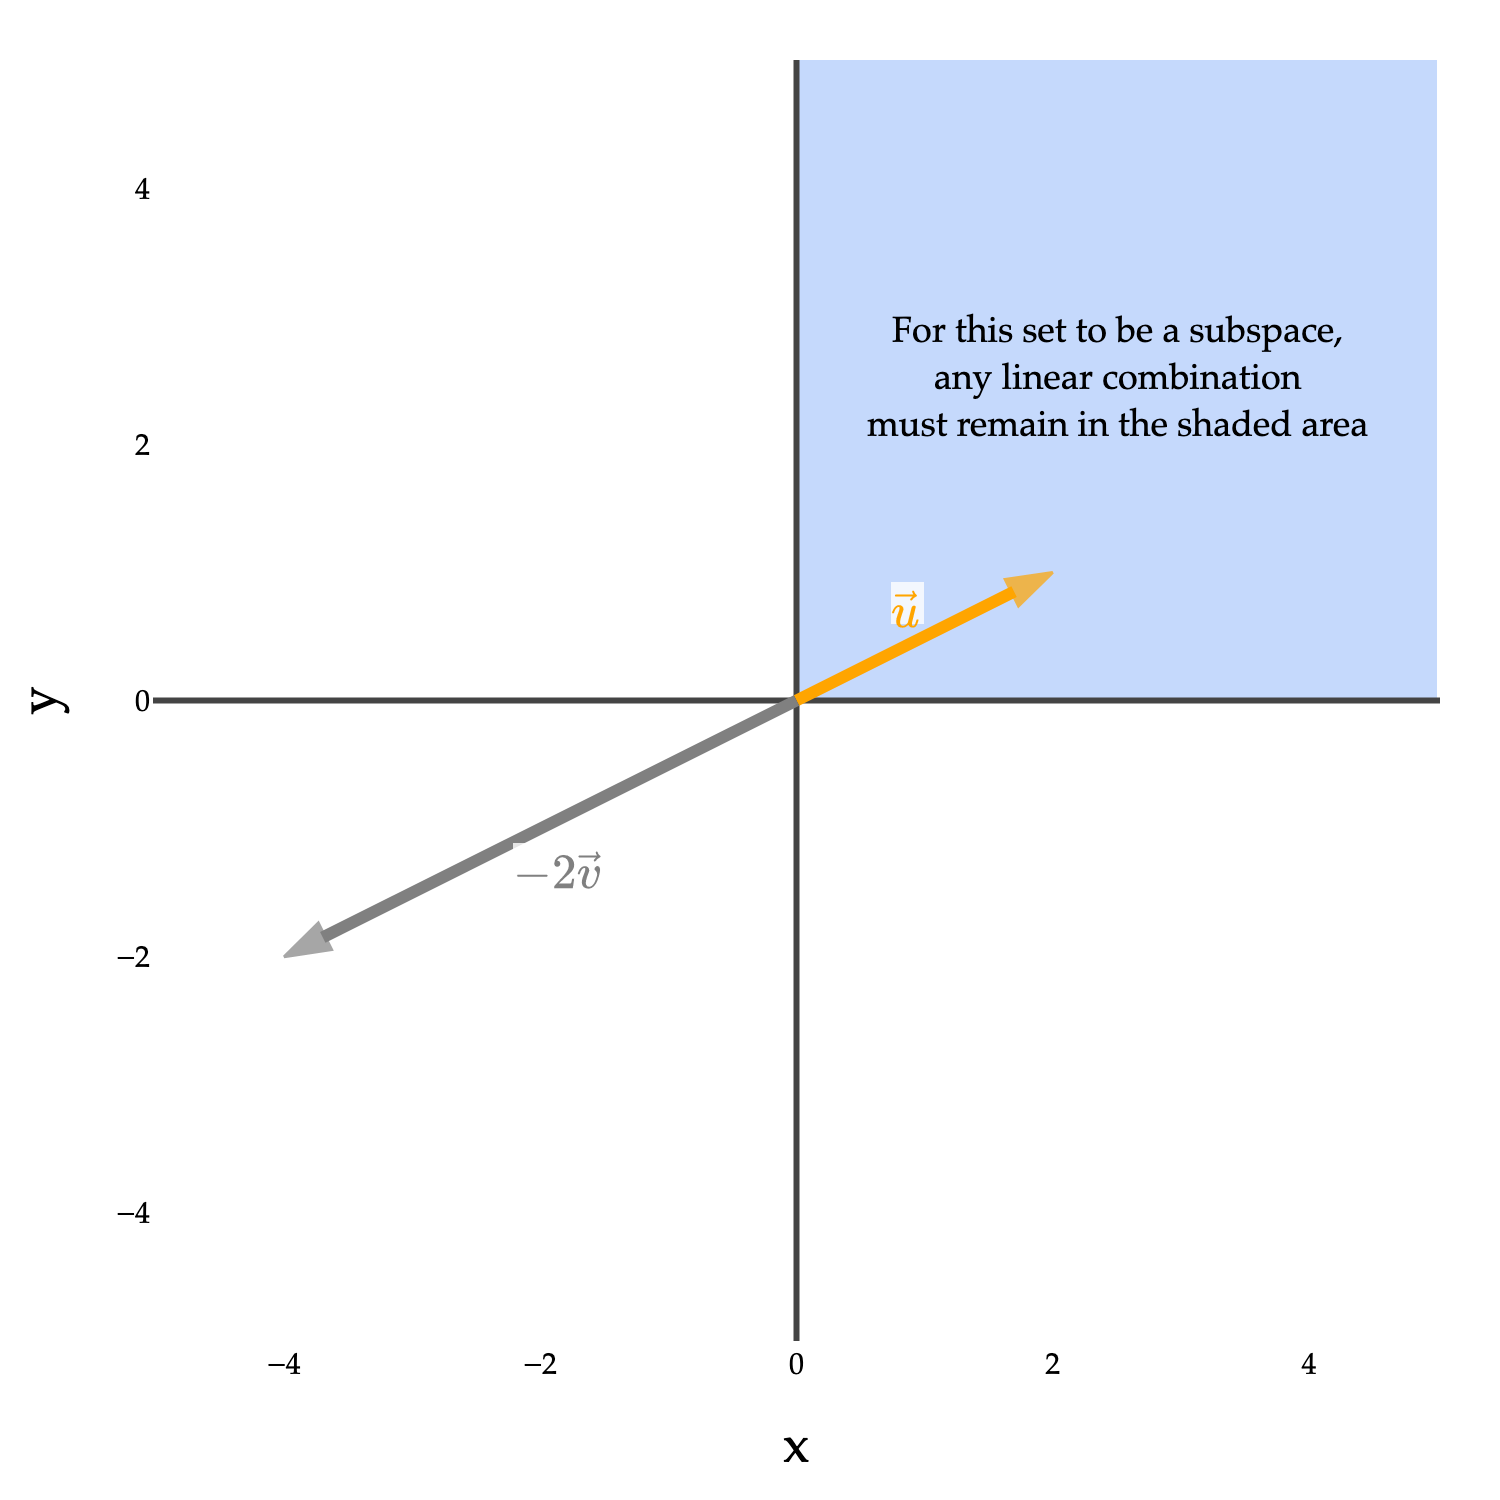

In [44]:
from utils import plot_vectors
import plotly.express as px
import plotly.graph_objects as go

fig = plot_vectors([((2, 1), "orange", r"$$\vec u$$"), ((-4, -2), "gray", r"$$-2\vec v$$")], vdeltay=0.3)

fig.update_xaxes(
    range=[-5, 5],
    showgrid=False,
    gridcolor="#f0f0f0",
    zeroline=True,
    zerolinecolor="#444",
    zerolinewidth=2,
    showline=False,
)
fig.update_yaxes(
    range=[-5, 5],
    showgrid=False,
    gridcolor="#f0f0f0",
    zeroline=True,
    zerolinecolor="#444",
    zerolinewidth=2,
    showline=False,
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Palatino",
    margin=dict(l=20, r=20, t=20, b=20),
    xaxis_title="x",
    yaxis_title="y",
    xaxis=dict(
        scaleanchor="y",
        scaleratio=1,
    ),
    width=500,
    height=500
)

fig.add_shape(
    type="rect",
    x0=0, y0=0, x1=5, y1=5,
    fillcolor="#3d81f6",
    opacity=0.3,
    layer="below",
    line_width=0,
)

fig.add_annotation(
    x=2.5,
    y=2.5,
    text="For this set to be a subspace,<br>any linear combination<br>must remain in the shaded area",
    showarrow=False,
    font=dict(
        family="Palatino",
        size=12,
    ),
    align="center",
    # bgcolor="#3d81f6",
    # bordercolor="#3d81f6",
    # borderwidth=2,
    # borderpad=4,
)

fig.show(renderer='png', scale=3)


### Example: Line through Origin ✅

Consider the set of all vectors in $\mathbb{R}^3$ that lie on the line spanned by $\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}$. Is this a set a subspace of $\mathbb{R}^3$? This is the set

$$\{ \begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix} \mid t \in \mathbb{R} \}$$

Visually, this line looks like

In [43]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (1, -3, 2)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 100)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([((0, 0, 0), "#3d81f6", r"")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Draw small points at (0, 0, 0) and the tip of v
fig.add_trace(
    go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode="markers",
        marker=dict(size=4, color=["#222", "#222"]),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add annotations next to the two points: (0,0,0) and (2,-1,3)
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="text",
        text=["(0, 0, 0)"],
        textposition="top right",
        showlegend=False,
        hoverinfo="skip"
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[v[0]],
        y=[v[1]],
        z=[v[2]],
        mode="text",
        text=[f"({v[0]}, {v[1]}, {v[2]})"],
        textposition="top center",
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add f0f0f0 lines at x=0, y=0, z=0 (non-removable)
axis_range = np.array([[-6, 6], [-6, 6], [-6, 6]])
# x-axis line (y=0, z=0)
fig.add_trace(
    go.Scatter3d(
        x=axis_range[0],
        y=[0, 0],
        z=[0, 0],
        mode="lines",
        line=dict(color="#aaa", width=1),
        showlegend=False,
        hoverinfo="skip"
    )
)
# y-axis line (x=0, z=0)
fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=axis_range[1],
        z=[0, 0],
        mode="lines",
        line=dict(color="#aaa", width=1),
        showlegend=False,
        hoverinfo="skip"
    )
)
# z-axis line (x=0, y=0)
fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=[0, 0],
        z=axis_range[2],
        mode="lines",
        line=dict(color="#aaa", width=1),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    scene=dict(
        xaxis=dict(range=[-4, 4]),
        yaxis=dict(range=[-4, 4]),
        zaxis=dict(range=[-6, 6]),
        aspectmode="cube"
    ),
)

fig.show()

If we pick any two vectors on this line, any of their linear combinations will also lie on this line. Any vector on this line is a scalar multiple of $\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}$, so two arbitrary vectors on this line might look like

$${\color{orange}\vec u = a\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v = b\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}}$$

Then, a linear combination of $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$ is

$$c{\color{orange}\vec u} + d{\color{#3d81f6}\vec v} = c {\color{orange}a\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}} + d {\color{#3d81f6}b\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}} = (c{\color{orange}a} + d{\color{#3d81f6}b})\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}$$

which is just another vector on the line! So, since the set is closed under linear combinations, it <span style="color:#3d81f6; font-weight:bold">is a subspace</span> of $\mathbb{R}^3$.

---

## Spans are Subspaces

The last example we walked through above, $\{{ \begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix} \mid t \in \mathbb{R} \}}$, is a subspace of $\mathbb{R}^3$. It is also the span of the vector $\begin{bmatrix} 1 \\ -3 \\ 2 \end{bmatrix}$. It turns out that this correspondence between spans and subspaces is true in general.

:::{attention} Spans are Subspaces

If ${\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}$ are vectors in $\mathbb{R}^n$, then the **span** (i.e. set of all possible linear combinations) of these vectors is a subspace of $\mathbb{R}^n$.

In other words,

$$\text{span}(\{{\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}\}) = \left\{a_1{\color{#3d81f6}\vec v_1} + a_2{\color{#3d81f6}\vec v_2} + \cdots + a_d{\color{#3d81f6}\vec v_d} \;\middle\vert\; a_1, a_2, \ldots, a_d \in \mathbb{R}\right\}$$

is a subspace of $\mathbb{R}^n$.
:::

This is true essentially by the definition of a span. The span of a collection of vectors is defined to be the set of all of their possible linear combinations. If you pick any two vectors in the span, they're both made of the same building blocks (spanning vectors), so if you make a linear combination of these two new vectors, that'll still be made up of the same building blocks.

### Example: Span of Two Vectors in $\mathbb{R}^3$ ✅

As an example, consider the span of the vectors

$${\color{orange}\vec u = \begin{bmatrix} 2 \\ 6 \\ -3 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v = \begin{bmatrix} 1 \\ 5 \\ 0 \end{bmatrix}}$$

$\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$ contains all vectors of the form $c{\color{orange}\vec u} + d{\color{#3d81f6}\vec v}$. Let's pick two such vectors, say $$\vec x =2{\color{orange}\vec u} + 3{\color{#3d81f6}\vec v}, \quad \vec y =4{\color{orange}\vec u} - 2{\color{#3d81f6}\vec v}$$

Both $\vec x$ and $\vec y$ are in $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$. Now, let's take a linear combination of these two new vectors, say, $5 \vec x - \frac{1}{2} \vec y$, and check if that's also in $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$. This linear combination is

$$5 \vec x - \frac{1}{2} \vec y = 5(2{\color{orange}\vec u} + 3{\color{#3d81f6}\vec v}) - \frac{1}{2}(4{\color{orange}\vec u} - 2{\color{#3d81f6}\vec v})$$

But, simplifying this expression shows us that it's equivalent to

$$5 \vec x - \frac{1}{2} \vec y = 10{\color{orange}\vec u} + 15{\color{#3d81f6}\vec v} - 2{\color{orange}\vec u} + {\color{#3d81f6}\vec v} = 8{\color{orange}\vec u} + 16{\color{#3d81f6}\vec v}$$

which clearly shows that a linear combination of $\vec x$ and $\vec y$ is really just a linear combination of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$.

All of this is to say, if you pick any two vectors in $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$, their linear combinations will also be in $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$, so $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$ is closed under addition and scalar multiplication. It also contains the zero vector (since you could take $0{\color{orange}\vec u} + 0{\color{#3d81f6}\vec v} = \vec 0$), so this span <span style="color:#3d81f6; font-weight:bold">is a subspace</span> of $\mathbb{R}^3$.

Let's not forget that the span of two non-collinear vectors in $\mathbb{R}^3$ is a plane. So, since $\text{span}(\{{\color{orange}\vec u}, {\color{#3d81f6}\vec v}\})$ is a subspace, the corresponding plane is also a subspace of $\mathbb{R}^3$ (because it's the same thing as the span of the vectors).

In [72]:
import numpy as np
import plotly.graph_objects as go
from utils import plot_vectors

# Define the two spanning vectors
u = np.array([2, 6, -3])   # orange
v = np.array([1, 5, 0])    # blue

# To plot the plane spanned by u and v, create a grid of linear combinations
plane_extent = 5
num_points = 20
s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
S, T = np.meshgrid(s_range, t_range)

# Compute all points s*u + t*v
X = S * u[0] + T * v[0]
Y = S * u[1] + T * v[1]
Z = S * u[2] + T * v[2]

fig = plot_vectors([
    (tuple(u), "orange", "u"),
    (tuple(v), "#3d81f6", "v"),
], vdeltax=3
, vdeltay=2)

# Plot the plane
fig.add_trace(go.Surface(
    x=X,
    y=Y,
    z=Z,
    opacity=0.4,
    colorscale=[[0, 'rgba(61,129,246,0.8)'], [1, 'rgba(61,129,246,0.8)']],
    showscale=False,
))

# Add faint lines at x=0, y=0, z=0
line_range = [-5, 5]
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=line_range, z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=line_range, y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=line_range,
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))

# # Draw the two spanning vectors from the origin
# vectors = [
#     dict(x=u[0], y=u[1], z=u[2], color='orange'),
#     dict(x=v[0], y=v[1], z=v[2], color='#3d81f6')
# ]
# for vtx in vectors:
#     fig.add_trace(go.Scatter3d(
#         x=[0, vtx['x']],
#         y=[0, vtx['y']],
#         z=[0, vtx['z']],
#         mode='lines+markers',
#         line=dict(color=vtx['color'], width=8),
#         marker=dict(size=4, color=vtx['color']),
#         showlegend=False
#     ))

fig.update_layout(
    scene=dict(
        xaxis=dict(
            range=[-10, 10],
            title='x',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        yaxis=dict(
            range=[-10, 10],
            title='y',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        zaxis=dict(
            range=[-12, 12],
            title='z',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        aspectmode='cube',
    ),
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=1.2, y=2, z=1.2)
    ),
    font=dict(family='Palatino'),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

[Chapter 4.4](04-lines-planes-hyperplanes.ipynb) shows us how to find the equation of a plane in standard form ($ax + by + cz + d = 0$) given two non-collinear vectors in the plane. That specific equation in this case happens to be $15x - 3y + 4z = 0$, which means the set of vectors $\begin{bmatrix} x \\ y \\ z \end{bmatrix}$ that satisfy this equation form a subspace of $\mathbb{R}^3$.

### Example: Plane $x + y + z = 0$ ✅

What if we're instead given a plane, rather than the span of a collection of vectors?

:::{attention} Subspaces are Spans
Given any subspace of $\mathbb{R}^n$, there exists some collection of vectors in $\mathbb{R}^n$ that spans the subspace.
:::

It turns out that not only is every span a subspace, but every subspace can be spanned by some collection of vectors. The plane $x + y + z = 0$ <span style="color:#3d81f6; font-weight:bold">is a subspace</span> of $\mathbb{R}^3$. Can we write it as the span of a collection of vectors? Sure we can. We know that it only takes two non-collinear vectors to span a plane, so all we need to do is pick two vectors that lie in $x + y + z = 0$.

Arbitrarily, let's pick the vectors $\begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 1 \\ -3 \end{bmatrix}$. These vectors aren't collinear (as a reminder, this means that one is not a scalar multiple of the other), so they span a plane.

So, the plane $x + y + z = 0$ is the span of the vectors $\begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 1 \\ -3 \end{bmatrix}$, and so it's a subspace of $\mathbb{R}^3$. These are not the only two vectors that span this plane; there are infinitely many pairs of vectors that can be said to span this plane. I just picked a pair that happens to have nice numbers.

I've plotted the plane below, without the vectors $\begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 1 \\ -3 \end{bmatrix}$, to emphasize that you should think of planes **through the origin** as subspaces in their own right.

In [75]:
import numpy as np
import plotly.graph_objects as go

# Define the plane x + y + z = 0
plane_extent = 6
num_points = 20

x_range = np.linspace(-plane_extent, plane_extent, num_points)
y_range = np.linspace(-plane_extent, plane_extent, num_points)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = -x_grid - y_grid  # From x + y + z = 0

fig = go.Figure()

# Plot the plane
fig.add_trace(go.Surface(
    x=x_grid,
    y=y_grid,
    z=z_grid,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.8)'], [1, 'rgba(61,129,246,0.8)']],
    showscale=False,
))

# Add faint lines at x=0, y=0, z=0
line_range = [-5, 5]
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=line_range, z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=line_range, y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=line_range,
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))

fig.update_layout(
    scene=dict(
        xaxis=dict(
            range=[-5, 5],
            title='x₁',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        yaxis=dict(
            range=[-5, 5],
            title='x₂',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        zaxis=dict(
            range=[-10, 10],
            title='x₃',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        aspectmode='cube',
    ),
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    font=dict(family='Palatino'),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

### Example: Plane $x + y + z = 5$ ❌

What about a plane that **doesn't** pass through the origin? Is the plane $x + y + z = 5$ a subspace of $\mathbb{R}^3$?

In [84]:
import numpy as np
import plotly.graph_objects as go

# Define the plane x + y + z = 0
plane_extent = 6
num_points = 20

x_range = np.linspace(-plane_extent, plane_extent, num_points)
y_range = np.linspace(-plane_extent, plane_extent, num_points)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = -x_grid - y_grid + 5  # From x + y + z = 0

fig = go.Figure()

# Plot the plane
fig.add_trace(go.Surface(
    x=x_grid,
    y=y_grid,
    z=z_grid,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.8)'], [1, 'rgba(61,129,246,0.8)']],
    showscale=False,
))

# Add faint lines at x=0, y=0, z=0
line_range = [-5, 5]
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=line_range, z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=line_range, y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=line_range,
    mode='lines',
    line=dict(color='#f0f0f0', width=2),
    showlegend=False,
    hoverinfo='skip'
))

# Draw a black dot at the origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=7, color='black'),
    showlegend=False,
    hoverinfo='skip'
))

fig.update_layout(
    scene=dict(
        xaxis=dict(
            range=[-5, 5],
            title='x₁',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        yaxis=dict(
            range=[-5, 5],
            title='x₂',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        zaxis=dict(
            range=[-10, 10],
            title='x₃',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
        ),
        aspectmode='cube',
    ),
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=1.2, y=1.2, z=-1)
    ),
    font=dict(family='Palatino'),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

Remember, subspaces must contain the zero vector, but the vector $\begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$ doesn't satisfy $x + y + z = 5$. So, the plane $x + y + z = 5$ is not a subspace of $\mathbb{R}^3$.

Equivalently, you know that the span of any set of vectors must also always contain the zero vector, since you're always able to create the zero vector by taking 0 of each of the spanning vectors, $0{\color{#3d81f6}\vec v_1} + 0{\color{#3d81f6}\vec v_2} + \cdots + 0{\color{#3d81f6}\vec v_d} = \vec 0$. So, if a set does not contain the zero vector, it can't be the span of any set of vectors, but as we just saw, all subspaces must be spanned by some set of vectors. **If it can't be a span, it can't be a subspace**, and so the plane $x + y + z = 5$ <span style="color:#3d81f6; font-weight:bold">is not a subspace</span> of $\mathbb{R}^3$.

---

## Basis and Dimension

In [Chapter 4.2](02-linear-independence.ipynb), we looked at how to find linearly independent subsets with the same span as a given set of vectors. We like the vectors we're dealing with to be linearly independent, so that any of their linear combinations are unique and can only be created in one way. (This was proved in Chapter 4.2.) 

The specific example we looked at was

$$\vec v_1 = \begin{bmatrix} 3 \\ 4 \\ 0 \end{bmatrix}, \quad \vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix}, \quad \vec v_3 = \begin{bmatrix} -3 \\ -2 \\ 2 \end{bmatrix}, \quad \vec v_4 = \begin{bmatrix} 6 \\ 5 \\ -3 \end{bmatrix}, \quad \vec v_5 = \begin{bmatrix} 2 \\ 5 \\ 1 \end{bmatrix}$$

And, through the algorithm introduced at the bottom of that section, we found that the vectors $\vec v_1, \vec v_2, \vec v_5$ alone have the same span as the original set of 5 vectors, but are also linearly independent.

$$\text{span}(\{ \vec v_1, \vec v_2, \vec v_5 \}) = \text{span}(\{ \vec v_1, \vec v_2, \vec v_3, \vec v_4, \vec v_5 \})$$

The vectors $\vec v_3$ and $\vec v_4$ can be written as linear combinations of $\vec v_1, \vec v_2, \vec v_5$, so they are not needed to describe the span of the original set of 5 vectors. In particular,

$$\vec v_3 = - \vec v_1 + 2 \vec v_2, \quad \vec v_4 = 2 \vec v_1 -3 \vec v_2$$

There is a special name for a set of vectors that are both linearly independent and span a subspace, like $\vec v_1, \vec v_2, \vec v_5$ above.

:::{note} Definition: Basis
A **basis** for a subspace $S$ is a set of vectors that:
1. span all of $S$.
2. are linearly independent.
:::

In the example above, the vectors $\vec v_1, \vec v_2, \vec v_5$ are a basis for the span of the original set of 5 vectors, or equivalently, a basis for the subspace of $\mathbb{R}^3$ containing all of the vectors that can be written as linear combinations of the original 5 vectors.

Think of a basis as the minimum set of vectors you need to describe every vector in a subspace:
- If you remove a vector from a basis, you'll no longer be able to reach every vector in the subspace.
- If you add an extra vector to a basis, the new set will no longer be linearly independent.

:::{note} Definition: Dimension
The **dimension** of a subspace $S$, denoted $\dim(S)$, is the number of vectors in a basis for $S$.

All bases for a subspace have the same number of vectors; this number is the dimension.
:::

Again, continuing with the example above, since we've found a basis containing 3 vectors for the span of the original set of 5 vectors, the dimension of the span of the original set of 5 vectors is **3** (not 5). So, I might say

$$\dim(\text{span}(\{ \vec v_1, \vec v_2, \vec v_3, \vec v_4, \vec v_5 \})) = 3$$

A basis for a subspace is not unique. Sure, $\vec v_1, \vec v_2, \vec v_5$ is a basis for the span of the original set of 5 vectors, but so is $\vec v_3, \vec v_4, \vec v_5$, another collection of 3 vectors.

And, since both of these bases ($\vec v_1, \vec v_2, \vec v_5$ and $\vec v_3, \vec v_4, \vec v_5$) involve 3 linearly independent vectors in $\mathbb{R}^3$, they span **all** of $\mathbb{R}^3$. What's another set of linearly independent vectors in $\mathbb{R}^3$ that span $\mathbb{R}^3$? There's the easy choice, of $\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$.

### Standard Basis for $\mathbb{R}^n$

We say the **standard basis** for $\mathbb{R}^n$ is the set of vectors $\begin{bmatrix} 1 \\ 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \ldots, \begin{bmatrix} 0 \\ 0 \\ 0 \\ \vdots \\ 1 \end{bmatrix}$. Sometimes these vectors are written as $\vec e_1, \vec e_2, \ldots, \vec e_n$. In addition to being a basis for $\mathbb{R}^n$, they're also unit vectors, and orthogonal.

Since the standard basis for $\mathbb{R}^n$ is, well, a basis, and any basis for a subspace has the same number of elements, we know that $\mathbb{R}^n$ is $n$-dimensional.

In $\mathbb{R}^2$, the standard basis consists of $\vec e_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $\vec e_2 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$. $\vec e_1$ and $\vec e_2$ are linearly independent (neither is a scalar multiple of the other), and they span all of $\mathbb{R}^2$, which means that any other vector in $\mathbb{R}^2$ can be written as a linear combination of them.

Pick your favorite vector with two components, say $\begin{bmatrix} 5 \\ -12 \end{bmatrix}$, and you'll be able to write it as a linear combination of the standard basis.

$$\begin{bmatrix} 5 \\ -12 \end{bmatrix} = 5 \begin{bmatrix} 1 \\ 0 \end{bmatrix} - 12 \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \underbrace{5 \vec v_1 - 12 \vec v_2}_\text{linear combination of standard basis}$$

Let's look at a few more examples of possible bases for given subspaces.

### Examples

| Vectors | Are they a basis for... | Answer | Why? |
| -- | -- | -- | -- |
| $\begin{bmatrix} 1 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 \\ 5 \end{bmatrix}$ | $\mathbb{R}^2$ | Yes | They're linearly independent, and span all of $\mathbb{R}^2$. |
| $\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}$ | $\mathbb{R}^3$ | No | They're linearly independent, but don't span all of $\mathbb{R}^3$, since no linear combination of them can equal $\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$ (or any other vector with a nonzero third component). |
| $\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix}$ | $\mathbb{R}^3$ | Yes | They're linearly independent, and span all of $\mathbb{R}^3$. They're not the standard basis, but they're still a basis. |
| $\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}, \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix}$ | $\mathbb{R}^3$ | No | They span all of $\mathbb{R}^3$ but they're not linearly independent. $\mathbb{R}^3$ has dimension 3, so a basis for $\mathbb{R}^3$ must have 3 vectors. |

### Finding a Basis for a Subspace

Often, we'll need to find a basis for a given subspace. If the subspace in question is the span of a set of vectors, we can use the algorithm from the bottom of [Chapter 4.2](02-linear-independence.ipynb) to find a basis. 

```
given v_1, v_2, ..., v_d
initialize linearly independent set S = {v_1}
for i = 2 to d:
    if v_i is not a linear combination of S:
        add v_i to S
```

All this algorithm does is remove linearly dependent vectors from left to right, so that the remaining vectors are linearly independent.  

For example, if

$$\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}, \quad \vec v_2 = \begin{bmatrix} 1 \\ -2 \\ -3 \end{bmatrix}, \quad \vec v_3 = \begin{bmatrix} -3 \\ 0 \\ 1 \end{bmatrix}$$

A basis for $\text{span}\left( \left\{ \vec v_1, \vec v_2, \vec v_3 \right\} \right)$ is $\left\{ \vec v_1, \vec v_2 \right\}$, since these two vectors are linearly independent and span the same subspace as the original three vectors; $\vec v_3$ is a linear combination of $\vec v_1$ and $\vec v_2$, specifically $\vec v_3 = -2 \vec v_1 - \vec v_2$. 

Equivalently, $\{ \vec v_1, \vec v_3 \}$ is also a basis for the same subspace, since we can equivalently say $\vec v_2 = - 2 \vec v_1 - \vec v_3$. Either way, $\text{dim}\left( \text{span}\left( \left\{ \vec v_1, \vec v_2, \vec v_3 \right\} \right) \right) = 2$. 

See the bottom of [Chapter 4.2](02-linear-independence.ipynb) for another worked example.

What about subspaces that aren't expressed explicitly as a span – how do we find a basis for them? For instance, consider the subspace of $\mathbb{R}^3$ containing vectors $\begin{bmatrix} x \\ y \\ z \end{bmatrix}$ such that $2x - 3y + 4z = 0$. This is a plane through the origin, and so we know it's spanned by two non-collinear vectors in $\mathbb{R}^3$.

Some subspaces aren't explicitly expressed as a span, but we can still find a basis for them. We looked at an example of this earlier in this section, before we knew what a basis was. Specifically, we saw the plane of points $\begin{bmatrix} x \\ y \\ z \end{bmatrix}$ such that $x + y + z = 0$ is spanned by $\begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 1 \\ -3 \end{bmatrix}$. Since these two vectors are linearly independent, they form a basis for the subspace (a basis of dimension 2).

:::{tip} Activity 3
:class: dropdown

For each of the following subspaces, find **two** possible bases and state the dimension.

1. The subspace of $\mathbb{R}^3$ containing vectors $\begin{bmatrix} x \\ y \\ z \end{bmatrix}$ such that $2x - 3y + 4z = 0$.
1. The subspace of $\mathbb{R}^6$ containing vectors in which the third and fourth coordinates are 0.
:::